<a href="https://colab.research.google.com/github/OmarFarukNoman/Into-to-Machine-Learning/blob/main/Homework-7/Problem_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem-2(a)**

Device: cuda


100%|██████████| 170M/170M [00:12<00:00, 13.2MB/s]



Epoch=1
Training Loss: 1.5568, Training Accuracy: 0.4274
Validation Loss: 1.3440, Validation Accuracy: 0.5142

Epoch=2
Training Loss: 1.2000, Training Accuracy: 0.5696
Validation Loss: 1.2737, Validation Accuracy: 0.5552

Epoch=3
Training Loss: 1.0532, Training Accuracy: 0.6232
Validation Loss: 1.4564, Validation Accuracy: 0.4911

Epoch=4
Training Loss: 0.9641, Training Accuracy: 0.6572
Validation Loss: 1.1302, Validation Accuracy: 0.5993

Epoch=5
Training Loss: 0.8963, Training Accuracy: 0.6810
Validation Loss: 1.5222, Validation Accuracy: 0.5000

Epoch=6
Training Loss: 0.8517, Training Accuracy: 0.6990
Validation Loss: 1.2435, Validation Accuracy: 0.5788

Epoch=7
Training Loss: 0.8045, Training Accuracy: 0.7154
Validation Loss: 1.1187, Validation Accuracy: 0.6251

Epoch=8
Training Loss: 0.7708, Training Accuracy: 0.7283
Validation Loss: 1.2890, Validation Accuracy: 0.5851

Epoch=9
Training Loss: 0.7392, Training Accuracy: 0.7397
Validation Loss: 1.0128, Validation Accuracy: 0.6574



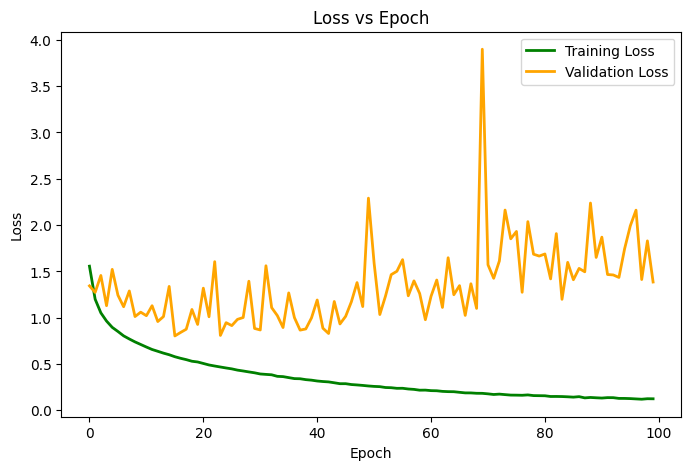

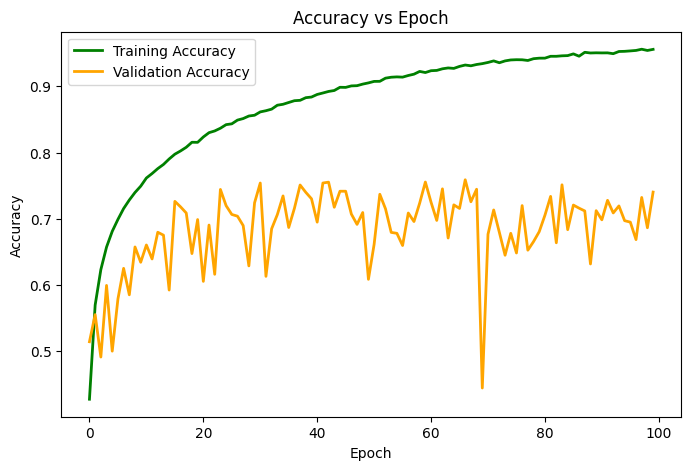

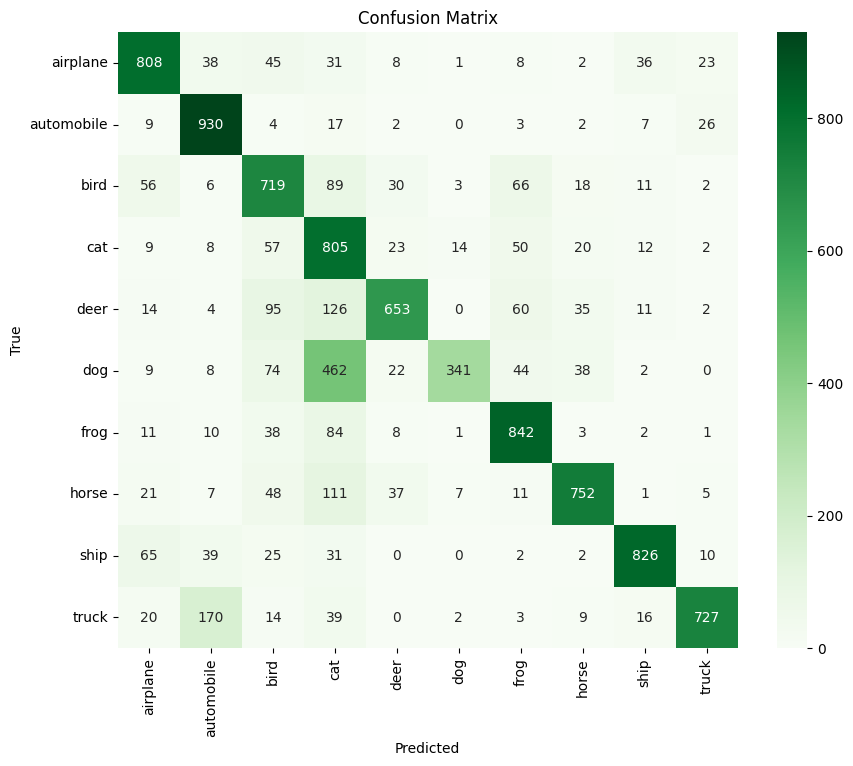

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010])
])

trainset = torchvision.datasets.CIFAR10(root="./data", train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=2)

valset = torchvision.datasets.CIFAR10(root="./data", train=False,
                                      download=True, transform=transform)
valloader = torch.utils.data.DataLoader(valset, batch_size=64,
                                        shuffle=False, num_workers=2)

classes = trainset.classes

# ResBlock (with BN + skip)
class ResBlock(nn.Module):
    def __init__(self, n_chans):
        super(ResBlock, self).__init__()
        self.conv = nn.Conv2d(
            n_chans, n_chans,
            kernel_size=3, padding=1, bias=False
        )
        self.batch_norm = nn.BatchNorm2d(num_features=n_chans)

        # Kaiming init
        torch.nn.init.kaiming_normal_(self.conv.weight,
                                      nonlinearity="relu")
        torch.nn.init.constant_(self.batch_norm.weight, 0.5)
        torch.nn.init.zeros_(self.batch_norm.bias)

    def forward(self, x):
        out = self.conv(x)
        out = self.batch_norm(out)
        out = F.relu(out)
        return out + x   # skip connection

# ResNet-10 model
class ResNet10(nn.Module):
    def __init__(self, n_chans=24, n_blocks=10, n_classes=10):
        super().__init__()
        self.n_chans = n_chans

        # Initial conv stem
        self.conv_in = nn.Conv2d(
            3, n_chans, kernel_size=3, padding=1, bias=False
        )
        self.bn_in = nn.BatchNorm2d(n_chans)

        # 10 residual blocks
        blocks = [ResBlock(n_chans) for _ in range(n_blocks)]
        self.blocks = nn.Sequential(*blocks)

        # Global average pooling + final linear layer
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(n_chans, n_classes)

        torch.nn.init.kaiming_normal_(self.conv_in.weight,
                                      nonlinearity="relu")

    def forward(self, x):
        # Stem: conv -> BN -> ReLU -> MaxPool (32x32 -> 16x16)
        out = self.conv_in(x)
        out = self.bn_in(out)
        out = F.relu(out)
        out = F.max_pool2d(out, 2)  # (B, C, 16, 16)

        # Residual blocks
        out = self.blocks(out)

        # Global average pool over 16x16 -> (B, C, 1, 1)
        out = self.global_pool(out)
        out = out.view(out.size(0), -1)  # (B, C)

        # Class logits
        out = self.fc(out)
        return out

# instantiate slimmer ResNet-10
net = ResNet10(n_chans=24, n_blocks=10, n_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.0015)


train_losses = []
val_losses = []
train_accs = []
val_accs = []

num_epochs = 100
start_time = time.time()

for epoch in range(num_epochs):

    # Training
    net.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = net(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, pred = torch.max(outputs, 1)
        total_train += y.size(0)
        correct_train += (pred == y).sum().item()

    avg_train_loss = running_loss / len(trainloader)
    train_acc = correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    # Validation
    net.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for x, y in valloader:
            x, y = x.to(device), y.to(device)
            outputs = net(x)

            loss = criterion(outputs, y)
            running_val_loss += loss.item()

            _, pred = torch.max(outputs, 1)
            total_val += y.size(0)
            correct_val += (pred == y).sum().item()

    avg_val_loss = running_val_loss / len(valloader)
    val_acc = correct_val / total_val
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch={epoch+1}"
          f"\nTraining Loss: {avg_train_loss:.4f}, Training Accuracy: {train_acc:.4f}"
          f"\nValidation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

# Training time
end_time = time.time()
print(f"\nTotal Training Time: {end_time - start_time:.2f} seconds\n")

# Model Size
def model_summary(model):
    print("\nModel Size\n")
    total_params = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            n = param.numel()
            total_params += n
            print(f"{name:25} --> {n} parameters")
    print(f"\nTotal Trainable Parameters: {total_params:,}\n")

model_summary(net)

# Loss
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss", linewidth=2, color="Green")
plt.plot(val_losses, label="Validation Loss", linewidth=2, color="Orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Training Accuracy", linewidth=2, color="Green")
plt.plot(val_accs, label="Validation Accuracy", linewidth=2, color="Orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

# Confusion Matrix
all_preds = []
all_labels = []

net.eval()
with torch.no_grad():
    for x, y in valloader:
        x = x.to(device)
        outputs = net(x)
        _, pred = torch.max(outputs, 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, cmap="Greens", fmt="d",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()



**Problem-2(b)**

Device: cuda


100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s]


[Weight Decay Only] Epoch=1 
Training Loss: 1.5654, Training Accuracy: 0.4304
Validation Loss: 2.0508, Validation Accuracy: 0.3384

[Weight Decay Only] Epoch=2 
Training Loss: 1.2302, Training Accuracy: 0.5570
Validation Loss: 1.5164, Validation Accuracy: 0.4598

[Weight Decay Only] Epoch=3 
Training Loss: 1.1060, Training Accuracy: 0.6035
Validation Loss: 1.2997, Validation Accuracy: 0.5507

[Weight Decay Only] Epoch=4 
Training Loss: 1.0216, Training Accuracy: 0.6347
Validation Loss: 1.7113, Validation Accuracy: 0.4532

[Weight Decay Only] Epoch=5 
Training Loss: 0.9567, Training Accuracy: 0.6598
Validation Loss: 1.3880, Validation Accuracy: 0.4979

[Weight Decay Only] Epoch=6 
Training Loss: 0.9159, Training Accuracy: 0.6756
Validation Loss: 1.3974, Validation Accuracy: 0.5239

[Weight Decay Only] Epoch=7 
Training Loss: 0.8707, Training Accuracy: 0.6910
Validation Loss: 1.4152, Validation Accuracy: 0.5045

[Weight Decay Only] Epoch=8 
Training Loss: 0.8361, Training Accuracy: 0.706

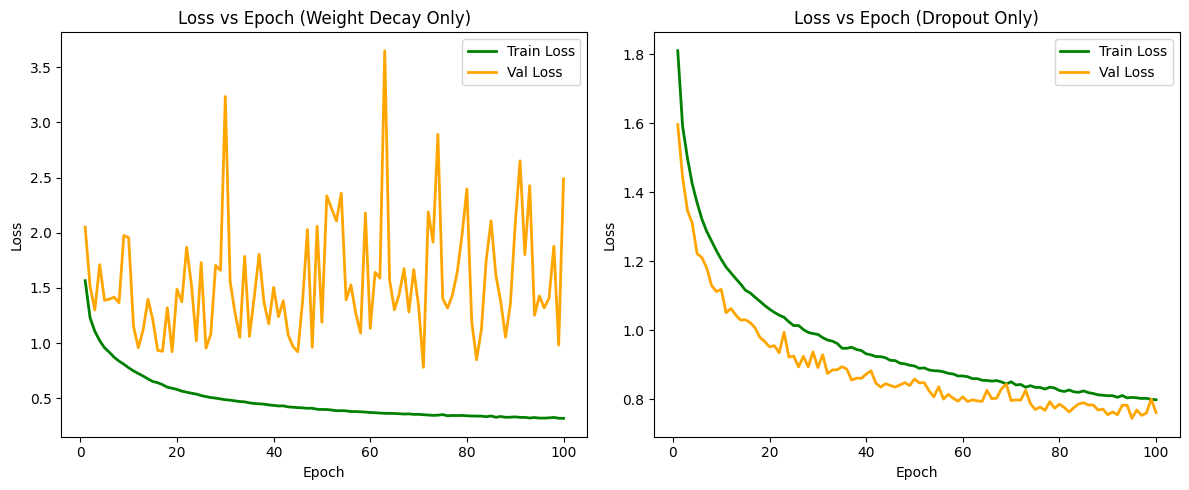

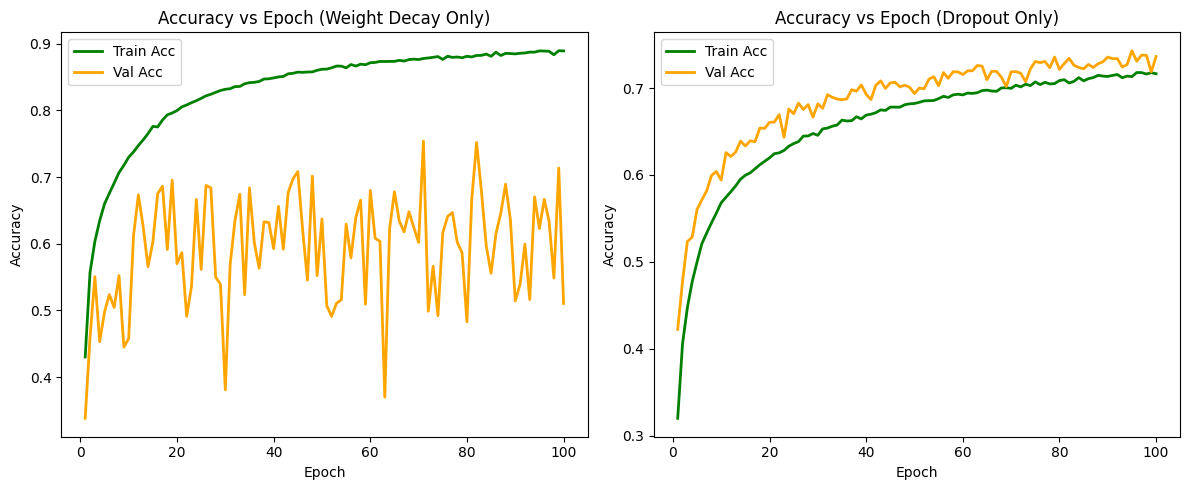

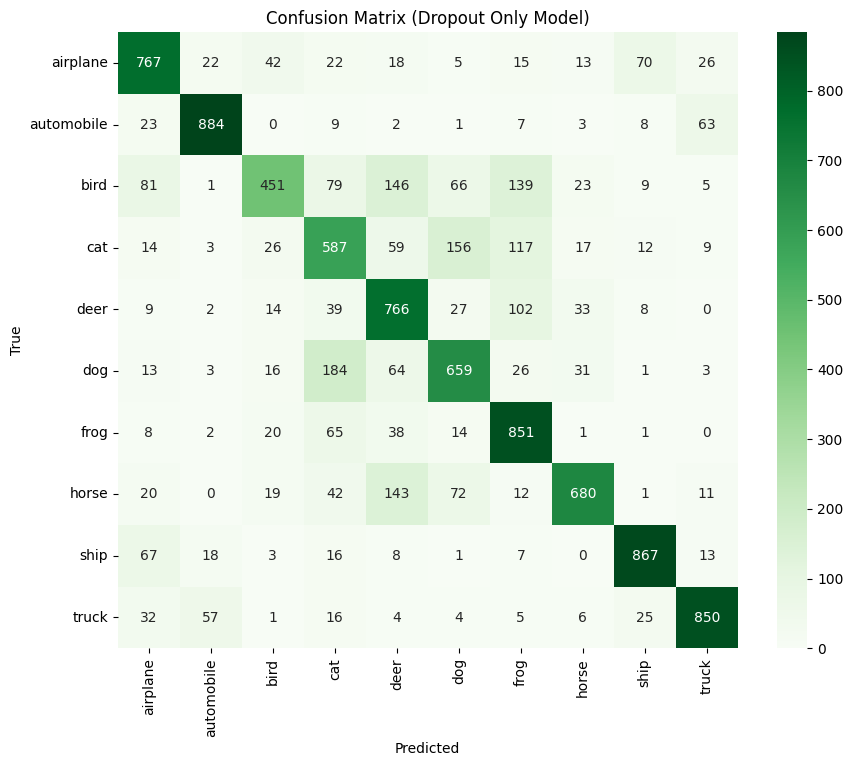

In [ ]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# CIFAR-10 data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010])
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2
)

valset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)
valloader = torch.utils.data.DataLoader(
    valset, batch_size=64, shuffle=False, num_workers=2
)

classes = trainset.classes

# ResNet-10 building blocks
class ResBlock(nn.Module):
    """Residual block with Conv + BN + ReLU + skip connection."""
    def __init__(self, n_chans):
        super(ResBlock, self).__init__()
        self.conv = nn.Conv2d(
            n_chans, n_chans,
            kernel_size=3, padding=1, bias=False
        )
        self.batch_norm = nn.BatchNorm2d(num_features=n_chans)

        # Kaiming init
        torch.nn.init.kaiming_normal_(self.conv.weight,
                                      nonlinearity="relu")
        torch.nn.init.constant_(self.batch_norm.weight, 0.5)
        torch.nn.init.zeros_(self.batch_norm.bias)

    def forward(self, x):
        out = self.conv(x)
        out = self.batch_norm(out)
        out = F.relu(out)
        return out + x   # skip connection


class ResBlockDropout(nn.Module):
    """Residual block with Conv + BN + ReLU + Dropout2d + skip."""
    def __init__(self, n_chans, p=0.3):
        super(ResBlockDropout, self).__init__()
        self.conv = nn.Conv2d(
            n_chans, n_chans,
            kernel_size=3, padding=1, bias=False
        )
        self.batch_norm = nn.BatchNorm2d(num_features=n_chans)
        self.dropout = nn.Dropout2d(p=p)

        torch.nn.init.kaiming_normal_(self.conv.weight,
                                      nonlinearity="relu")
        torch.nn.init.constant_(self.batch_norm.weight, 0.5)
        torch.nn.init.zeros_(self.batch_norm.bias)

    def forward(self, x):
        out = self.conv(x)
        out = self.batch_norm(out)
        out = F.relu(out)
        out = self.dropout(out)   # dropout after activation
        return out + x


class ResNet10(nn.Module):
    """
    ResNet-10 for CIFAR-10.
    Can use either ResBlock (BN only) or ResBlockDropout (BN + dropout).
    """
    def __init__(self, block_cls, n_chans=24, n_blocks=10,
                 n_classes=10, dropout_p=0.3):
        super().__init__()
        self.n_chans = n_chans

        # Initial conv stem
        self.conv_in = nn.Conv2d(
            3, n_chans, kernel_size=3, padding=1, bias=False
        )
        self.bn_in = nn.BatchNorm2d(n_chans)
        torch.nn.init.kaiming_normal_(self.conv_in.weight,
                                      nonlinearity="relu")

        # Stack of residual blocks
        if block_cls is ResBlockDropout:
            blocks = [block_cls(n_chans, p=dropout_p) for _ in range(n_blocks)]
        else:
            blocks = [block_cls(n_chans) for _ in range(n_blocks)]
        self.blocks = nn.Sequential(*blocks)

        # Global average pooling + final linear layer
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(n_chans, n_classes)

    def forward(self, x):
        # Stem: conv -> BN -> ReLU -> MaxPool (32x32 -> 16x16)
        out = self.conv_in(x)
        out = self.bn_in(out)
        out = F.relu(out)
        out = F.max_pool2d(out, 2)  # (B, C, 16, 16)

        # Residual blocks
        out = self.blocks(out)

        # Global average pool over 16x16 -> (B, C, 1, 1)
        out = self.global_pool(out)
        out = out.view(out.size(0), -1)  # (B, C)

        # Class logits
        out = self.fc(out)
        return out


criterion = nn.CrossEntropyLoss()

# Helper: training function
def train_model(net, optimizer, num_epochs, trainloader, valloader, device, label=""):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    start_time = time.time()
    for epoch in range(num_epochs):

        # Training
        net.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for x, y in trainloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = net(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_train += y.size(0)
            correct_train += (predicted == y).sum().item()

        avg_train_loss = running_loss / len(trainloader)
        train_acc = correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)

        # Validation
        net.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for x, y in valloader:
                x, y = x.to(device), y.to(device)

                outputs = net(x)
                loss = criterion(outputs, y)
                running_val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total_val += y.size(0)
                correct_val += (predicted == y).sum().item()

        avg_val_loss = running_val_loss / len(valloader)
        val_acc = correct_val / total_val
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)

        print(f"[{label}] Epoch={epoch+1} "
              f"\nTraining Loss: {avg_train_loss:.4f}, Training Accuracy: {train_acc:.4f}"
              f"\nValidation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_acc:.4f}\n")

    end_time = time.time()
    training_time = end_time - start_time
    print(f"[{label}] Total Training Time: {training_time:.2f} seconds\n")

    return train_losses, val_losses, train_accs, val_accs, training_time

# Weight Decay ONLY (no dropout)
num_epochs = 100

net_wd = ResNet10(
    block_cls=ResBlock,   # no dropout in the block
    n_chans=24,
    n_blocks=10,
    n_classes=10
).to(device)

optimizer_wd = torch.optim.Adam(
    net_wd.parameters(),
    lr=0.001,
    weight_decay=0.001    # weight decay for regularization
)

wd_train_losses, wd_val_losses, wd_train_accs, wd_val_accs, wd_time = train_model(
    net_wd, optimizer_wd, num_epochs, trainloader, valloader, device, label="Weight Decay Only"
)


# Dropout ONLY (no weight decay)
net_do = ResNet10(
    block_cls=ResBlockDropout,  # dropout in the block
    n_chans=24,
    n_blocks=10,
    n_classes=10,
    dropout_p=0.3
).to(device)

optimizer_do = torch.optim.Adam(
    net_do.parameters(),
    lr=0.001,
    weight_decay=0.0      # NO weight decay here
)

do_train_losses, do_val_losses, do_train_accs, do_val_accs, do_time = train_model(
    net_do, optimizer_do, num_epochs, trainloader, valloader, device, label="Dropout Only"
)


# Model Size (example: print for dropout model)
def model_summary(model):
    print("\nModel Size\n")
    total_params = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            n = param.numel()
            total_params += n
            print(f"{name:25} --> {n} parameters")
    print(f"\nTotal Trainable Parameters: {total_params:,}\n")

print("=== Weight Decay Only Model Summary ===")
model_summary(net_wd)

print("=== Dropout Only Model Summary ===")
model_summary(net_do)

# PLOTS: LOSSES (two subplots)
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))

# Left: weight decay
plt.subplot(1, 2, 1)
plt.plot(epochs, wd_train_losses, label="Train Loss", linewidth=2, color="green")
plt.plot(epochs, wd_val_losses, label="Val Loss", linewidth=2, color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch (Weight Decay Only)")
plt.legend()

# Right: dropout
plt.subplot(1, 2, 2)
plt.plot(epochs, do_train_losses, label="Train Loss", linewidth=2, color="green")
plt.plot(epochs, do_val_losses, label="Val Loss", linewidth=2, color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch (Dropout Only)")
plt.legend()

plt.tight_layout()
plt.show()


# PLOTS: ACCURACIES (two subplots)
plt.figure(figsize=(12,5))

# Left: weight decay
plt.subplot(1, 2, 1)
plt.plot(epochs, wd_train_accs, label="Train Acc", linewidth=2, color="green")
plt.plot(epochs, wd_val_accs, label="Val Acc", linewidth=2, color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch (Weight Decay Only)")
plt.legend()

# Right: dropout
plt.subplot(1, 2, 2)
plt.plot(epochs, do_train_accs, label="Train Acc", linewidth=2, color="green")
plt.plot(epochs, do_val_accs, label="Val Acc", linewidth=2, color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch (Dropout Only)")
plt.legend()

plt.tight_layout()
plt.show()

# Confusion Matrix (example: Dropout-only model)
all_preds = []
all_labels = []

net_do.eval()
with torch.no_grad():
    for x, y in valloader:
        x = x.to(device)
        outputs = net_do(x)
        _, pred = torch.max(outputs, 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, cmap="Greens", fmt="d",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Dropout Only Model)")
plt.show()